# Singular-Value Pseudoinverse Deblurring

This notebook solves a small one-dimensional deblurring inverse problem with `singular_value_pseudoinverse_workflow`. The forward operator is a finite convolution blur matrix, the data are blurred measurements, and the package workflow applies a truncated singular-value pseudoinverse polynomial to recover the signal.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** The measured signal is a blurred version of a sparse smooth source. Small singular values of the blur operator amplify measurement noise, so the inverse problem needs regularization.

**QSVT implementation.** The package workflow normalizes singular values, designs a bounded inverse-like polynomial above a cutoff, applies the polynomial pseudoinverse action, and compares against a dense truncated-SVD reference.

**Classical reference and quantum relevance.** The dense SVD reference validates the finite example. In a QSVT setting, the singular-value inverse polynomial is the transform core for a block encoding of the rectangular forward model, with state preparation, readout, and success-probability management handled separately.

## Variable definitions

- `n_points`: number of grid samples.
- `grid`: one-dimensional sample grid.
- `blur`: finite convolution blur matrix.
- `true_signal`: unknown source signal.
- `observed`: blurred measurement vector.
- `result`: package pseudoinverse workflow result.
- `solution`: polynomial pseudoinverse reconstruction.
- `reference_solution`: dense truncated-SVD reconstruction.
- `naive_solution`: unregularized dense least-squares reconstruction.
- `relative_signal_error`: reconstruction error against the known synthetic signal.
- `fig`, `axes`, and similar names are plotting helpers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import singular_value_pseudoinverse_workflow

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 24
grid = np.linspace(0.0, 1.0, n_points)
indices = np.arange(n_points)
sigma = 2.0

blur = np.empty((n_points, n_points), dtype=float)
for i in range(n_points):
    distances = np.abs(indices - i)
    distances = np.minimum(distances, n_points - distances)
    row = np.exp(-0.5 * (distances / sigma) ** 2)
    blur[i] = row / np.sum(row)

true_signal = (
    1.0 * np.exp(-0.5 * ((grid - 0.28) / 0.055) ** 2)
    + 0.65 * np.exp(-0.5 * ((grid - 0.68) / 0.075) ** 2)
)
structured_noise = 0.015 * np.sin(2 * np.pi * 7 * grid)
observed = blur @ true_signal + structured_noise

result = singular_value_pseudoinverse_workflow(
    blur,
    observed,
    degree=30,
    cutoff=0.28,
    num_points=1201,
)

solution = np.real(result.polynomial_solution)
reference_solution = np.real(result.reference_solution)
naive_solution = np.linalg.lstsq(blur, observed, rcond=None)[0]

relative_signal_error = np.linalg.norm(solution - true_signal) / np.linalg.norm(true_signal)
reference_signal_error = np.linalg.norm(reference_solution - true_signal) / np.linalg.norm(true_signal)
naive_signal_error = np.linalg.norm(naive_solution - true_signal) / np.linalg.norm(true_signal)

print(f"polynomial residual norm: {result.residual_norm:.4f}")
print(f"solution relative error vs truncated SVD: {result.solution_relative_error:.4f}")
print(f"signal reconstruction error: {relative_signal_error:.4f}")

polynomial residual norm: 0.0606
solution relative error vs truncated SVD: 0.1145
signal reconstruction error: 0.2002


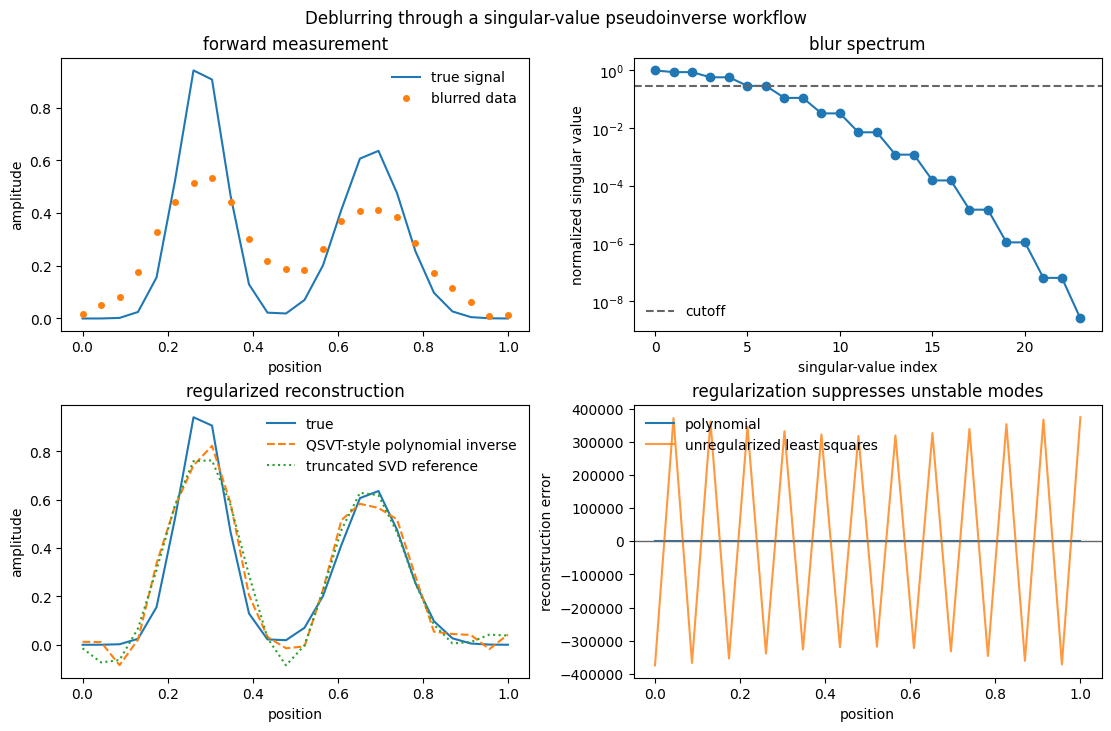

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

axes[0, 0].plot(grid, true_signal, label="true signal")
axes[0, 0].plot(grid, observed, "o", label="blurred data", markersize=4)
axes[0, 0].set_xlabel("position")
axes[0, 0].set_ylabel("amplitude")
axes[0, 0].set_title("forward measurement")
axes[0, 0].legend(frameon=False)

axes[0, 1].semilogy(result.normalized_singular_values, "o-")
axes[0, 1].axhline(result.cutoff, color="0.4", linestyle="--", label="cutoff")
axes[0, 1].set_xlabel("singular-value index")
axes[0, 1].set_ylabel("normalized singular value")
axes[0, 1].set_title("blur spectrum")
axes[0, 1].legend(frameon=False)

axes[1, 0].plot(grid, true_signal, label="true")
axes[1, 0].plot(grid, solution, "--", label="QSVT-style polynomial inverse")
axes[1, 0].plot(grid, reference_solution, ":", label="truncated SVD reference")
axes[1, 0].set_xlabel("position")
axes[1, 0].set_ylabel("amplitude")
axes[1, 0].set_title("regularized reconstruction")
axes[1, 0].legend(frameon=False)

axes[1, 1].plot(grid, solution - true_signal, label="polynomial")
axes[1, 1].plot(grid, naive_solution - true_signal, label="unregularized least squares", alpha=0.8)
axes[1, 1].axhline(0.0, color="0.4", linewidth=1.0)
axes[1, 1].set_xlabel("position")
axes[1, 1].set_ylabel("reconstruction error")
axes[1, 1].set_title("regularization suppresses unstable modes")
axes[1, 1].legend(frameon=False)

fig.suptitle("Deblurring through a singular-value pseudoinverse workflow")
plt.show()

In [4]:
report = result.as_report()
assert report["mode"] == "singular-value-pseudoinverse-workflow"
assert result.solution_relative_error < 0.12
assert relative_signal_error < naive_signal_error
assert abs(relative_signal_error - reference_signal_error) < 0.08

print(f"polynomial_vs_truncated_svd_error: {result.solution_relative_error:.4f}")
print(f"regularized_signal_error: {relative_signal_error:.4f}")
print(f"naive_least_squares_signal_error: {naive_signal_error:.4f}")
print("validation: passed")

polynomial_vs_truncated_svd_error: 0.1145
regularized_signal_error: 0.2002
naive_least_squares_signal_error: 899062.9002
validation: passed
